In [1]:
%load_ext autoreload
%autoreload 2
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import torch.nn.functional as F

from architectures import BetaVAE
from utils import linear_interpolation, prepare_masked_image, calculate_lpips
import random
import lpips

### visualization of some generated cats

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = BetaVAE(latent_dim=32).to(device)

weights_path = "./vae_results/best_model_final_200epochs.pth" 
try:
    model.load_state_dict(torch.load(weights_path, map_location=device))
    print("Weights loaded successfully!")
except FileNotFoundError:
    print(f"Error: File {weights_path} not found. Make sure it's in the same folder as the script.")

model.eval()

Using device: cpu
Weights loaded successfully!


C:\Users\macie\AppData\Local\Temp\ipykernel_23220\3273291463.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights_path, map_location=

BetaVAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
    (8): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=4096, out_features=32, bias=True)
  (fc_logvar): Linear(in_features=4096, out_features=32, bias=True)
  (decoder_input): Linear(in_features=32, out_features=4096, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose

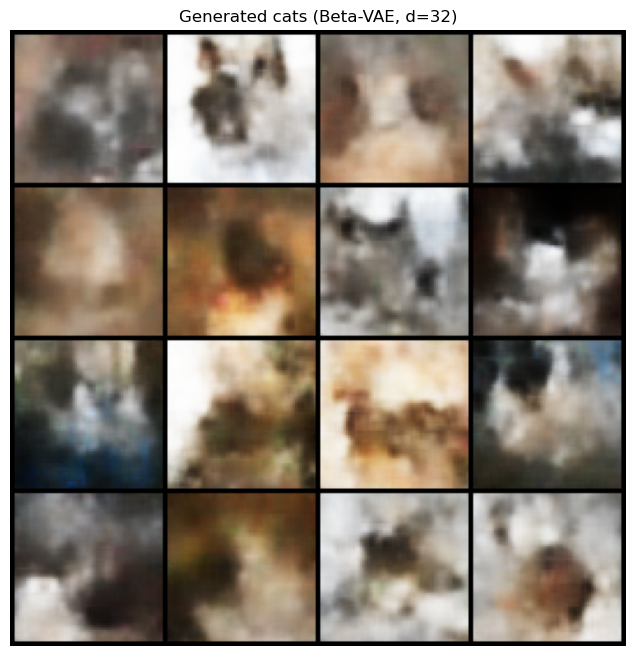

In [26]:
num_cats_to_generate = 16
with torch.no_grad():
    z_random = torch.randn(num_cats_to_generate, 32).to(device)
    
    generated_images = model.decode(z_random)

grid = vutils.make_grid(generated_images, nrow=4, padding=2, normalize=False).cpu()

grid_np = grid.permute(1, 2, 0).numpy()

plt.figure(figsize=(8, 8))
plt.imshow(grid_np)
plt.axis("off")
plt.title("Generated cats (Beta-VAE, d=32)")
plt.show()

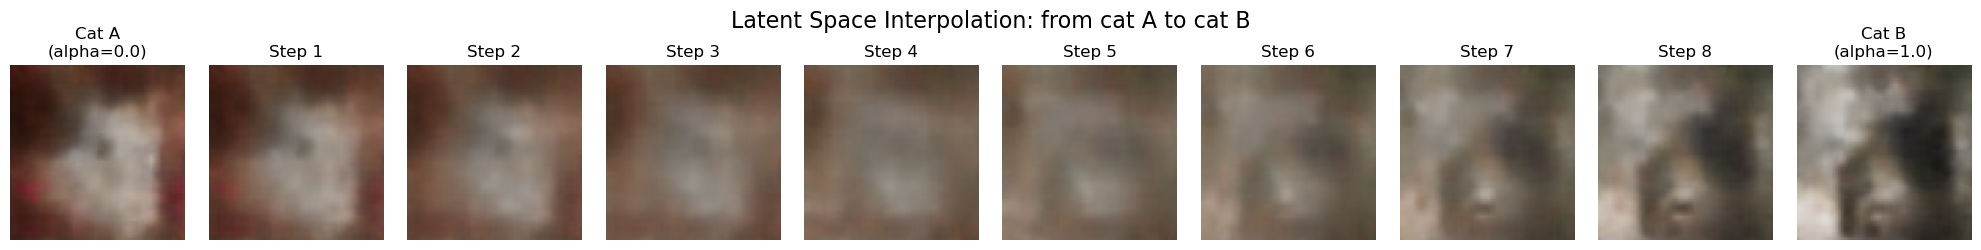

In [27]:
random_number = random.randint(0, 1000)
torch.manual_seed(random_number)

with torch.no_grad():
    z1 = torch.randn(32).to(device)
    z2 = torch.randn(32).to(device)

    z_interp = linear_interpolation(z1, z2, num_steps=10).to(device)

    generated_images = model.decode(z_interp)

fig, axes = plt.subplots(1, 10, figsize=(20, 2.5))
fig.suptitle("Latent Space Interpolation: from cat A to cat B", fontsize=16)

for i in range(10):
    img = generated_images[i].cpu().permute(1, 2, 0).numpy()
    
    axes[i].imshow(img)
    axes[i].axis("off")
    
    if i == 0:
        axes[i].set_title("Cat A\n(alpha=0.0)")
    elif i == 9:
        axes[i].set_title("Cat B\n(alpha=1.0)")
    else:
        axes[i].set_title(f"Step {i}")

plt.tight_layout()
plt.show()

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


c:\Users\macie\anaconda3\envs\melanoma_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\macie\anaconda3\envs\melanoma_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: c:\Users\macie\anaconda3\envs\melanoma_env\Lib\site-packages\lpips\weights\v0.1\vgg.pth

--- INPAINTING RESULTS (24x24 patch) ---
MSE:   0.1884
LPIPS: 0.6733


c:\Users\macie\anaconda3\envs\melanoma_env\Lib\site-packages\lpips\lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(model_path, ma

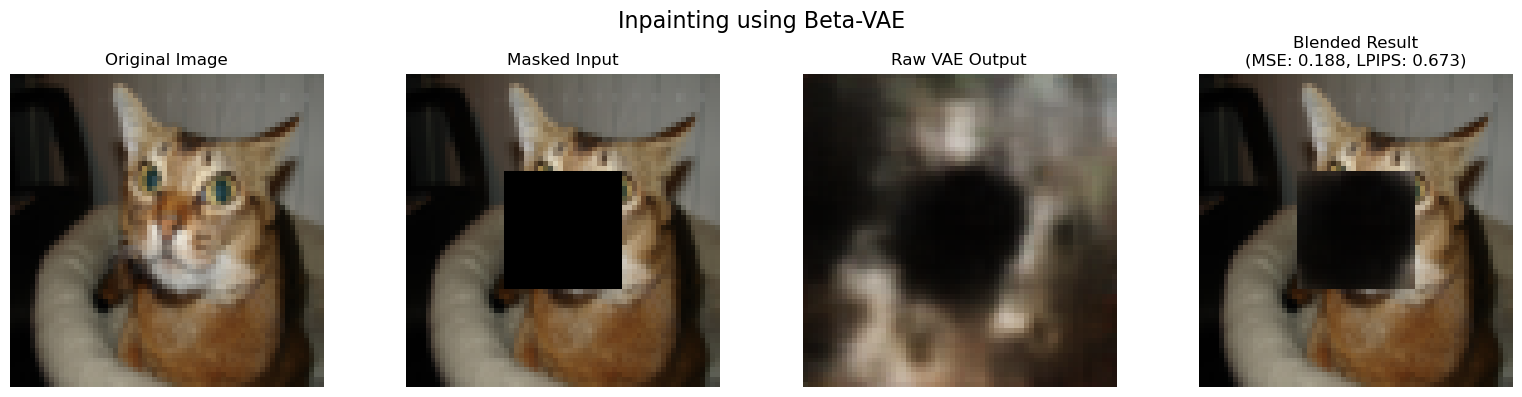

In [ ]:
loss_fn_vgg = lpips.LPIPS(net='vgg').to(device)


image_path = "test_cat.jpg" 

try:
    real_img, masked_img, mask = prepare_masked_image(
        image_path=image_path, 
        device=device, 
        mask_size=24, 
        img_size=64
    )
except FileNotFoundError as e:
    print(e)
    raise 


with torch.no_grad():
    recon_img, _, _ = model(masked_img)

    blended_img = (real_img * (1.0 - mask)) + (recon_img * mask)


real_patch = real_img[:, :, 20:44, 20:44]
recon_patch = recon_img[:, :, 20:44, 20:44]

mse_val = F.mse_loss(recon_patch, real_patch).item()

lpips_val = calculate_lpips(loss_fn_vgg, real_patch, recon_patch)

print(f"\n--- INPAINTING RESULTS (24x24 patch) ---")
print(f"MSE:   {mse_val:.4f}")
print(f"LPIPS: {lpips_val:.4f}")


def to_numpy(tensor):
    return tensor.squeeze(0).permute(1, 2, 0).cpu().numpy().clip(0, 1)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Inpainting using Beta-VAE", fontsize=16)

axes[0].imshow(to_numpy(real_img))
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(to_numpy(masked_img))
axes[1].set_title("Masked Input")
axes[1].axis("off")

axes[2].imshow(to_numpy(recon_img))
axes[2].set_title("Raw VAE Output")
axes[2].axis("off")

axes[3].imshow(to_numpy(blended_img))
axes[3].set_title(f"Blended Result\n(MSE: {mse_val:.3f}, LPIPS: {lpips_val:.3f})")
axes[3].axis("off")

plt.tight_layout()
plt.show()